# Caso de Estudio: Análisis de la Tienda Online de Africam Safari

---

## Objetivo del proyecto

Este proyecto tiene como objetivo analizar la estructura comercial de la tienda en línea de Africam Safari mediante técnicas de web scraping y análisis de datos.

Se busca entender:
- la composición del catálogo de productos
- la estructura de precios
- la distribución de productos por tipo
- posibles estrategias comerciales implícitas

---

## Enfoque metodológico

El análisis se desarrollará en tres fases:

- **Extracción de datos**
  - Obtención de información directamente del sitio web
  - Construcción de un dataset estructurado

- **Limpieza y transformación**
  - Estandarización de variables
  - Conversión de precios a formato numérico

- **Análisis exploratorio**
  - Evaluación de precios
  - Distribución del catálogo
  - Identificación de patrones de negocio

---

## Alcance

Este caso de estudio se centra inicialmente en la categoría **Ropa**, como punto de partida para el análisis.

Posteriormente, el enfoque podrá ampliarse a otras categorías y compararse con tiendas similares.

---

## Herramientas utilizadas

- Python
- BeautifulSoup (web scraping)
- Pandas (análisis de datos)

---

## Consideraciones sobre los datos

Este análisis se basa exclusivamente en información pública obtenida del sitio web oficial de Africam Safari.

Los datos utilizados corresponden únicamente a la información visible para cualquier usuario y se emplean con fines educativos, analíticos y de portafolio.

---

## Resultado esperado

Generar insights accionables que puedan:
- apoyar la toma de decisiones comerciales
- servir como material de portafolio en análisis de datos
- utilizarse como caso de estudio en marca personal

# Conexión a la página principal

En esta etapa se verifica que Python puede conectarse correctamente al sitio web y obtener su contenido HTML.

Esto permite confirmar que la página puede ser utilizada como fuente de datos para el análisis.

In [12]:
# Código (conexión)

import requests
from bs4 import BeautifulSoup

url = "https://africamsafarishop.com/"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

soup = BeautifulSoup(response.text, "html.parser")

print(response.status_code)
print(soup.title.text.strip())


200
AFRICAM SAFARI SOUVENIRS
    
    
    
      – africamsouvenirs


---

# Exploración de enlaces

En esta etapa se identifican los enlaces disponibles dentro de la página.

El objetivo es:

- entender la estructura del sitio web  
- detectar rutas hacia categorías y productos  
- identificar patrones en las URLs que permitan automatizar la extracción de datos  

In [13]:
links = []

for link in soup.find_all("a"):
    href = link.get("href")
    if href:
        links.append(href)

# ver algunos ejemplos
links[:20]

['#MainContent',
 'https://www.instagram.com/africamsafaripuebla/',
 'https://www.facebook.com/africamsafari',
 'https://twitter.com/AfricamSafari',
 'https://www.tiktok.com/@africamsafari',
 'https://www.youtube.com/@AFRICAMSAFARIMX',
 '/collections/novedades',
 '/collections/gift-cards-1',
 '/collections/ropa',
 '/collections/accesorios-1',
 '/collections/hogar',
 '/collections/peluches-1',
 'https://africamsafari.com/guardianes-salvajes/',
 '/',
 '/cart',
 '/collections/novedades',
 '/collections/gift-cards-1',
 '/collections/ropa',
 '/collections/accesorios-1',
 '/collections/hogar']

---

# Filtrado de enlaces de categorías

En esta etapa se seleccionan únicamente los enlaces que apuntan a colecciones de productos.

Esto permite separar las categorías relevantes del resto de enlaces del sitio, como redes sociales, carrito o enlaces internos no útiles para el análisis.

In [14]:
collection_links = []

for link in links:
    if "/collections/" in link:
        collection_links.append(link)

collection_links

['/collections/novedades',
 '/collections/gift-cards-1',
 '/collections/ropa',
 '/collections/accesorios-1',
 '/collections/hogar',
 '/collections/peluches-1',
 '/collections/novedades',
 '/collections/gift-cards-1',
 '/collections/ropa',
 '/collections/accesorios-1',
 '/collections/hogar',
 '/collections/peluches-1',
 '/collections/novedades',
 '/collections/gift-cards-1',
 '/collections/ropa',
 '/collections/accesorios-1',
 '/collections/hogar',
 '/collections/peluches-1',
 '/collections/novedades',
 '/collections/gift-cards-1',
 '/collections/ropa',
 '/collections/ninos-1',
 '/collections/playeras-ninos',
 '/collections/sudaderas-ninos',
 '/collections/explorador-infantil',
 '/collections/dama',
 '/collections/playeras-dama',
 '/collections/sudaderas-dama',
 '/collections/explorador-dama',
 '/collections/hombre',
 '/collections/playeras-caballero',
 '/collections/sudaderas-caballero-1',
 '/collections/explorador-caballero',
 '/collections/accesorios-1',
 '/collections/calcetas',
 '/

---

# Limpieza de enlaces de categorías

En esta etapa se eliminan los enlaces duplicados para obtener una lista única de categorías.

Esto permite trabajar con una estructura más clara del catálogo y evitar procesar información repetida.

In [16]:
unique_collections = list(set(collection_links))

unique_collections

['/collections/sudaderas-dama',
 '/collections/accesorios-1',
 '/collections/bolsas-y-mochilas',
 '/collections/playeras-ninos',
 '/collections/gorras-1',
 '/collections/sombreros',
 '/collections/playeras-caballero',
 '/collections/calcetas',
 '/collections/ropa',
 '/collections/llaveros-1',
 '/collections/alcancias-1',
 '/collections/navajas-swiza',
 '/collections/playeras-2',
 '/collections/joyeria-1',
 '/collections/gift-cards-1',
 '/collections/sudaderas-caballero-1',
 '/collections/dama',
 '/collections/explorador-dama',
 '/collections/playeras-dama',
 '/collections/ninos-1',
 '/collections/imanes',
 '/collections/peluches-1',
 '/collections/explorador-infantil',
 '/collections/termos',
 '/collections/hogar',
 '/collections/novedades',
 '/collections/bandanas',
 '/collections/tazas',
 '/collections/explorador-caballero',
 '/collections/hombre',
 '/collections/recamara',
 '/collections/sudaderas-1',
 '/collections/sudaderas-ninos',
 '/collections/pantuflas-2',
 '/collections/didac

---

# Selección de categoría de análisis

Para este caso de estudio se selecciona la categoría **ropa** como punto de partida.

Esta categoría permite analizar una variedad representativa de productos, incluyendo diferentes tipos como playeras y sudaderas.

A partir de esta sección se comenzará la extracción de productos individuales.

In [17]:
base_url = "https://africamsafarishop.com"

category_url = base_url + "/collections/ropa"

category_url

'https://africamsafarishop.com/collections/ropa'

---

# Carga de la categoría seleccionada

En esta etapa se accede a la categoría **ropa** para analizar su contenido de forma independiente.

El objetivo es verificar que la página de la categoría responde correctamente y preparar el HTML para extraer los enlaces de productos.

In [18]:
response_cat = requests.get(category_url, headers=headers, timeout=20)

print(response_cat.status_code)

soup_cat = BeautifulSoup(response_cat.text, "html.parser")
print(soup_cat.title.text.strip())

200
ROPA
    
    
    
      – africamsouvenirs


---

# Extracción de enlaces de productos

En esta etapa se identifican los enlaces que corresponden a productos individuales dentro de la categoría seleccionada.

Estos enlaces contienen la ruta `/products/` y permitirán acceder a la información específica de cada producto.

In [19]:
product_links = []

for link in soup_cat.find_all("a"):
    href = link.get("href")
    
    if href and "/products/" in href:
        product_links.append(href)

product_links[:20]

['/collections/ropa/products/sudadera-lila-lemures-infantil',
 '/collections/ropa/products/sudadera-lila-lemures-infantil',
 '/collections/ropa/products/sudadera-verde-capibara-infantil',
 '/collections/ropa/products/sudadera-verde-capibara-infantil',
 '/collections/ropa/products/sudadera-azul-retro',
 '/collections/ropa/products/sudadera-azul-retro',
 '/collections/ropa/products/playera-camaleon-infantil',
 '/collections/ropa/products/playera-camaleon-infantil',
 '/collections/ropa/products/playera-gris-bordado-rino',
 '/collections/ropa/products/playera-gris-bordado-rino',
 '/collections/ropa/products/playera-jaguar-tribal',
 '/collections/ropa/products/playera-jaguar-tribal',
 '/collections/ropa/products/playera-rino-tribal',
 '/collections/ropa/products/playera-rino-tribal',
 '/collections/ropa/products/playera-oso-tribal',
 '/collections/ropa/products/playera-oso-tribal',
 '/collections/ropa/products/playera-aguila-tribal',
 '/collections/ropa/products/playera-aguila-tribal',
 '/c

---

# Limpieza de enlaces de productos

En esta etapa se eliminan los enlaces duplicados para obtener una lista única de productos.

Esto permite evitar procesar el mismo producto varias veces y garantiza un dataset más limpio.

In [20]:
unique_products = list(set(product_links))

unique_products[:20]


['/collections/ropa/products/sudadera-azul-retro',
 '/collections/ropa/products/playera-canguro-olivo',
 '/collections/ropa/products/playera-gris-bordado-rino',
 '/collections/ropa/products/chaleco-safari-infantil-olivo',
 '/collections/ropa/products/playera-aguila-tribal',
 '/collections/ropa/products/playera-leones-caballero',
 '/collections/ropa/products/vestido-infantil-verde-exploradora',
 '/collections/ropa/products/sudadera-lila-lemures-infantil',
 '/collections/ropa/products/overol-bebe-africam',
 '/collections/ropa/products/playera-manga-larga-leon',
 '/collections/ropa/products/playera-oso-tribal',
 '/collections/ropa/products/vestido-dama-exploradora',
 '/collections/ropa/products/playera-flamingo-dama-1',
 '/collections/ropa/products/playera-jaguar-tribal',
 '/collections/ropa/products/sudadera-jaguar-azul-marino',
 '/collections/ropa/products/playera-pavoreal-dama',
 '/collections/ropa/products/playera-manga-larga-rinoceronte',
 '/collections/ropa/products/playera-canguro-

---

# Construcción de URLs completas

En esta etapa se convierten los enlaces relativos de productos en URLs completas.

Esto es necesario para poder acceder directamente a cada página de producto y extraer su información.

In [23]:
full_product_links = []

for link in unique_products:
    full_product_links.append(base_url + link)

full_product_links[:10]

['https://africamsafarishop.com/collections/ropa/products/sudadera-azul-retro',
 'https://africamsafarishop.com/collections/ropa/products/playera-canguro-olivo',
 'https://africamsafarishop.com/collections/ropa/products/playera-gris-bordado-rino',
 'https://africamsafarishop.com/collections/ropa/products/chaleco-safari-infantil-olivo',
 'https://africamsafarishop.com/collections/ropa/products/playera-aguila-tribal',
 'https://africamsafarishop.com/collections/ropa/products/playera-leones-caballero',
 'https://africamsafarishop.com/collections/ropa/products/vestido-infantil-verde-exploradora',
 'https://africamsafarishop.com/collections/ropa/products/sudadera-lila-lemures-infantil',
 'https://africamsafarishop.com/collections/ropa/products/overol-bebe-africam',
 'https://africamsafarishop.com/collections/ropa/products/playera-manga-larga-leon']

---

# Lectura de un producto individual

En esta etapa se accede a una página de producto para identificar dónde se encuentra la información relevante dentro del HTML.

El objetivo es comprobar que es posible extraer variables como el nombre y el precio antes de automatizar el proceso para todo el catálogo.

In [24]:
test_product_url = full_product_links[0]

response_prod = requests.get(test_product_url, headers=headers, timeout=20)

print(response_prod.status_code)

soup_prod = BeautifulSoup(response_prod.text, "html.parser")
print(soup_prod.title.text.strip())

200
SUDADERA AZUL RETRO
    
    
    
      – africamsouvenirs


---

# Extracción inicial del nombre del producto

En esta etapa se identifica el nombre del producto dentro de la página individual.

Esto permite confirmar qué etiqueta HTML contiene el nombre y prepara la extracción estructurada de datos.

In [26]:
h1 = soup_prod.find("h1")
print(h1.text.strip() if h1 else "No se encontró h1")

SUDADERA AZUL RETRO


---

# Extracción inicial del precio del producto

En esta etapa se busca el precio visible dentro del HTML de la página de producto.

El objetivo es detectar su formato y comprobar que puede recuperarse automáticamente.

In [27]:
for span in soup_prod.find_all("span"):
    text = span.text.strip()
    if "$" in text and "MXN" in text:
        print(text)

$ 699.00 MXN


---

# Construcción del dataset de productos

En esta etapa se automatiza la extracción de información de todos los productos de la categoría seleccionada.

El objetivo es construir un dataset estructurado que contenga variables clave como nombre, precio y URL de cada producto.

In [30]:
import time
import pandas as pd

rows = []

for link in full_product_links:
    
    response_prod = requests.get(link, headers=headers, timeout=20)
    soup_prod = BeautifulSoup(response_prod.text, "html.parser")
    
    # nombre
    h1 = soup_prod.find("h1")
    product_name = h1.text.strip() if h1 else None
    
    # precio
    price = None
    for span in soup_prod.find_all("span"):
        text = span.text.strip()
        if "$" in text and "MXN" in text:
            price = text
            break
    
    rows.append({
        "product_name": product_name,
        "price": price,
        "product_url": link
    })
    
    time.sleep(1)

df = pd.DataFrame(rows)

df.head()

,product_name,price,product_url
0,SUDADERA AZUL RETRO,$ 699.00 MXN,https://africamsafarishop.com/collections/ropa...
1,PLAYERA CANGURO OLIVO,$ 270.00 MXN,https://africamsafarishop.com/collections/ropa...
2,PLAYERA GRIS BORDADO RINO,$ 350.00 MXN,https://africamsafarishop.com/collections/ropa...
3,CHALECO SAFARI INFANTIL OLIVO,$ 550.00 MXN,https://africamsafarishop.com/collections/ropa...
4,PLAYERA AGUILA TRIBAL,$ 350.00 MXN,https://africamsafarishop.com/collections/ropa...


---

# Limpieza de precios

En esta etapa se transforma la variable de precio a formato numérico para permitir su análisis.

Se eliminan símbolos como "$" y "MXN", y se convierte el valor a tipo float.

In [32]:
df["price_clean"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace("MXN", "", regex=False)
    .str.strip()
    .astype(float)
)

df.head()

,product_name,price,product_url,price_clean
0,SUDADERA AZUL RETRO,$ 699.00 MXN,https://africamsafarishop.com/collections/ropa...,699.0
1,PLAYERA CANGURO OLIVO,$ 270.00 MXN,https://africamsafarishop.com/collections/ropa...,270.0
2,PLAYERA GRIS BORDADO RINO,$ 350.00 MXN,https://africamsafarishop.com/collections/ropa...,350.0
3,CHALECO SAFARI INFANTIL OLIVO,$ 550.00 MXN,https://africamsafarishop.com/collections/ropa...,550.0
4,PLAYERA AGUILA TRIBAL,$ 350.00 MXN,https://africamsafarishop.com/collections/ropa...,350.0


---

# Análisis exploratorio de precios

En esta etapa se analizan las características básicas de los precios de los productos.

Se busca entender:
- rango de precios
- precio promedio
- distribución general

In [33]:
df["price_clean"].describe()

count     24.000000
mean     425.416667
std      141.468361
min      250.000000
25%      350.000000
50%      350.000000
75%      550.000000
max      699.000000
Name: price_clean, dtype: float64

In [34]:
df.sort_values("price_clean", ascending=False).head(5)

,product_name,price,product_url,price_clean
0,SUDADERA AZUL RETRO,$ 699.00 MXN,https://africamsafarishop.com/collections/ropa...,699.0
14,SUDADERA JAGUAR AZUL MARINO,$ 659.00 MXN,https://africamsafarishop.com/collections/ropa...,659.0
11,VESTIDO DAMA EXPLORADORA,$ 630.00 MXN,https://africamsafarishop.com/collections/ropa...,630.0
21,SUDADERA VERDE CAPIBARA INFANTIL,$ 599.00 MXN,https://africamsafarishop.com/collections/ropa...,599.0
7,SUDADERA LILA LÉMURES INFANTIL,$ 599.00 MXN,https://africamsafarishop.com/collections/ropa...,599.0


In [35]:
df.sort_values("price_clean").head(5)

,product_name,price,product_url,price_clean
5,PLAYERA LEONES CABALLERO,$ 250.00 MXN,https://africamsafarishop.com/collections/ropa...,250.0
22,PLAYERA LEONES DAMA,$ 250.00 MXN,https://africamsafarishop.com/collections/ropa...,250.0
1,PLAYERA CANGURO OLIVO,$ 270.00 MXN,https://africamsafarishop.com/collections/ropa...,270.0
17,PLAYERA CANGURO BEIGE,$ 270.00 MXN,https://africamsafarishop.com/collections/ropa...,270.0
18,PLAYERA CAMALEÓN INFANTIL,$ 285.00 MXN,https://africamsafarishop.com/collections/ropa...,285.0


---

# Insights iniciales sobre precios

El análisis de precios muestra una estructura escalonada clara dentro del catálogo:

- Productos de entrada (~250–300 MXN): principalmente playeras
- Productos de gama media (~300–500 MXN)
- Productos premium (~550–700 MXN): sudaderas y prendas más complejas

Esto sugiere una estrategia comercial basada en distintos niveles de acceso para el cliente, permitiendo desde compras impulsivas hasta productos de mayor valor.

Además, se observa que las prendas como sudaderas y vestidos concentran los precios más altos, lo que indica un posicionamiento de mayor valor percibido dentro del catálogo.

In [36]:
# Variable estratégica

def classify_product(name):
    name = name.lower()
    
    if "sudadera" in name:
        return "sudadera"
    elif "playera" in name:
        return "playera"
    elif "chaleco" in name:
        return "chaleco"
    elif "vestido" in name:
        return "vestido"
    else:
        return "otro"

df["product_type"] = df["product_name"].apply(classify_product)

df.head()

,product_name,price,product_url,price_clean,product_type
0,SUDADERA AZUL RETRO,$ 699.00 MXN,https://africamsafarishop.com/collections/ropa...,699.0,sudadera
1,PLAYERA CANGURO OLIVO,$ 270.00 MXN,https://africamsafarishop.com/collections/ropa...,270.0,playera
2,PLAYERA GRIS BORDADO RINO,$ 350.00 MXN,https://africamsafarishop.com/collections/ropa...,350.0,playera
3,CHALECO SAFARI INFANTIL OLIVO,$ 550.00 MXN,https://africamsafarishop.com/collections/ropa...,550.0,chaleco
4,PLAYERA AGUILA TRIBAL,$ 350.00 MXN,https://africamsafarishop.com/collections/ropa...,350.0,playera


---

# Análisis por tipo de producto

En esta etapa se analiza cómo se distribuyen los productos según su tipo y cómo varían los precios entre ellos.

El objetivo es identificar:
- qué tipo de producto domina el catálogo
- qué tipo tiene precios más altos
- posibles estrategias comerciales por categoría

In [37]:
# conteo por tipo
# qué vende más la tienda?

df["product_type"].value_counts()

playera     15
sudadera     4
chaleco      2
vestido      2
otro         1
Name: product_type, dtype: int64

In [39]:
# precio promedio por tipo
# qué tipo genera más valor?

df.groupby("product_type")["price_clean"].mean().sort_values(ascending=False)

product_type
sudadera    639.000000
vestido     585.000000
chaleco     550.000000
otro        499.000000
playera     325.666667
Name: price_clean, dtype: float64

In [41]:
# resumen completo
df.groupby("product_type")["price_clean"].describe()

,count,mean,std,min,25%,50%,75%,max
product_type,,,,,,,,
chaleco,2.0,550.000000,0.000000,550.0,550.0,550.0,550.0,550.0
otro,1.0,499.000000,NaN,499.0,499.0,499.0,499.0,499.0
playera,15.0,325.666667,46.247265,250.0,277.5,350.0,350.0,380.0
sudadera,4.0,639.000000,48.989795,599.0,599.0,629.0,669.0,699.0
vestido,2.0,585.000000,63.639610,540.0,562.5,585.0,607.5,630.0


---

# Insights por tipo de producto

El análisis por categoría revela una estrategia comercial claramente segmentada:

- **Playeras**:
  - Representan la mayoría del catálogo
  - Precio promedio de ~325 MXN
  - Funcionan como productos de entrada (alto volumen)

- **Sudaderas**:
  - Precio promedio de ~639 MXN
  - Representan la gama premium
  - Probablemente enfocadas en margen

- **Chalecos y vestidos**:
  - Menor presencia en el catálogo
  - Precios intermedios (~550–585 MXN)
  - Posible enfoque en nichos específicos

Se identifica un modelo de negocio basado en:
- productos accesibles para atraer clientes
- productos premium para incrementar ingresos por unidad

Adicionalmente, se detecta un posible vacío en el rango de precios medio (~400–500 MXN), lo que podría representar una oportunidad de expansión del catálogo.

---
---

# Distribución de precios

Se analiza cómo se distribuyen los precios de los productos dentro del catálogo.

Esto permite identificar concentraciones, rangos dominantes y posibles gaps en la estrategia de precios.

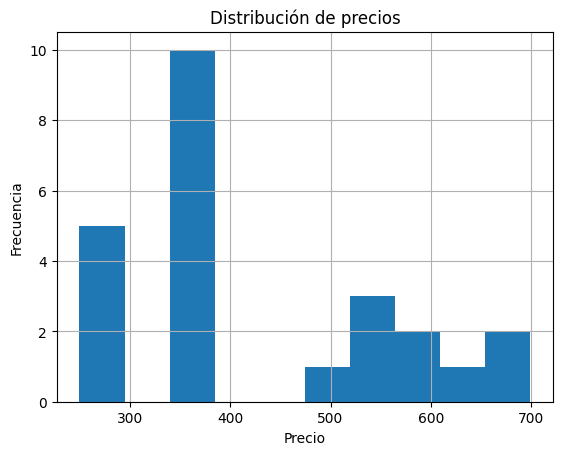

In [43]:
import matplotlib.pyplot as plt

plt.figure()

df["price_clean"].hist()

plt.title("Distribución de precios")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")

plt.show()

---

# Distribución de productos por tipo

Se analiza la cantidad de productos por categoría para entender qué tipo domina el catálogo.

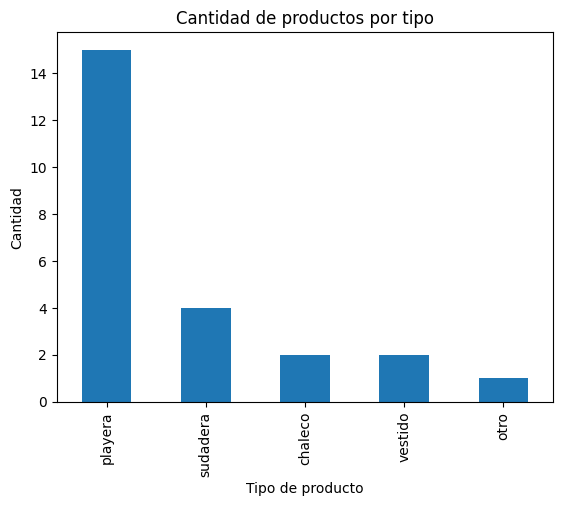

In [45]:
df["product_type"].value_counts().plot(kind="bar")

plt.title("Cantidad de productos por tipo")
plt.xlabel("Tipo de producto")
plt.ylabel("Cantidad")

plt.show()

---

# Precio promedio por tipo de producto

Se analiza el precio promedio por categoría para identificar qué tipo de producto genera mayor valor.

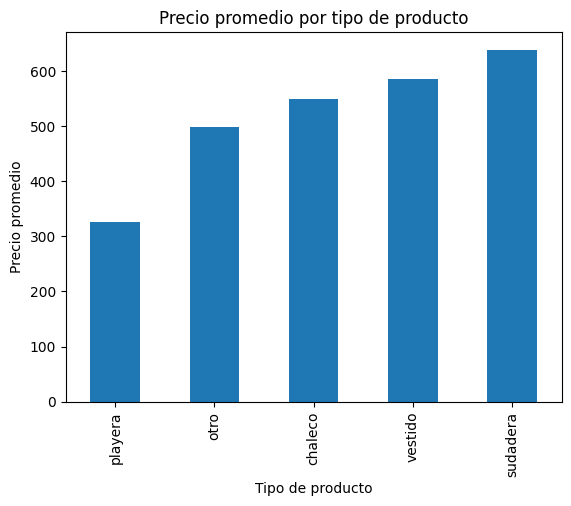

In [46]:
df.groupby("product_type")["price_clean"].mean().sort_values().plot(kind="bar")

plt.title("Precio promedio por tipo de producto")
plt.xlabel("Tipo de producto")
plt.ylabel("Precio promedio")

plt.show()

---
---

# Conclusiones del análisis

El análisis revela una estructura comercial claramente segmentada:

- Alta concentración de productos en la categoría de playeras, indicando una estrategia orientada a volumen.
- Distribución de precios bimodal:
  - productos accesibles (~250–380 MXN)
  - productos premium (~550–700 MXN)
- Presencia de un vacío en el rango medio (~400–500 MXN), lo que sugiere una oportunidad de expansión.
- Las sudaderas concentran los precios más altos, posicionándose como productos de mayor valor.

En conjunto, el catálogo responde a un modelo basado en:
- alto volumen en productos de entrada
- mayor margen en productos premium

---

# Recomendaciones estratégicas

A partir de los hallazgos, se proponen las siguientes acciones:

- **Desarrollar productos en el rango medio (~400–500 MXN)**  
  para capturar demanda intermedia y cerrar el gap identificado.

- **Expandir la línea premium (sudaderas)**  
  mediante mayor variedad o diferenciación, maximizando ingresos por unidad.

- **Optimizar productos de entrada (playeras)**  
  con estrategias de volumen como promociones o bundles.

- **Revisar categorías con baja presencia**  
  (chalecos, vestidos) para evaluar su potencial o redefinir su rol en el catálogo.

---

# Conclusión general

El negocio muestra una estrategia clara de segmentación por precio, combinando productos de entrada con productos premium. La optimización del rango medio representa una oportunidad directa para mejorar la estructura comercial del catálogo.

---
